# Testing the YOLO model $z$-Axis Detection

Having tested the model on spots, we now want to assess the performance using a reference stack of glass beads provided by the Taute Lab

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")

import matplotlib.patches as patches
from matplotlib import colormaps as cmaps
import os
from tqdm import tqdm
import yaml
from importlib import reload  # Python 3.4+
import pandas as pd

import image_generator as ig

from yundon_functions import *
pi = np.pi
from multiprocessing import Pool
from PIL import Image
from cv2 import resize
from itertools import repeat
from matplotlib.patches import Rectangle, Circle
# %matplotlib widget
import cv2
from ultralytics.utils import ops
from YOLOtrack11 import YOLOtrack11
from scipy.stats import binned_statistic

def plot_result(ax,img,objects, vmin=1.95e4, vmax=2.05e4):
    if isinstance(img, PIL.Image.Image) or isinstance(img, np.ndarray):
        pass
    elif(type(img) == str):
        img = PIL.Image.open(img)
    ax.imshow(img,cmap="grey",vmin=vmin,vmax=vmax)
    ax.axis("off")
    for i,obj in objects.iterrows():
        l,x,y,w,h = obj[:5]
        rect = Rectangle((x-0.5*w,y-0.5*h),h,w, linewidth=1, edgecolor="yellow", facecolor='none')
        tx,ty = rect.get_xy()
        ax.add_patch(rect)
        tx+=6
        ty-=12
        circle = Circle((x,y),1, facecolor="red",edgecolor="red")
        ax.add_patch(circle)
        if l == "Ripple":
            ax.text(tx,ty,f"{obj["z"]*0.134:.3f}",fontsize="small",bbox=dict(facecolor='white', alpha=0.5,))
def plot_gt(path,ax,imgsz=[512,512],vmin=1.95e4,vmax=2.05e4):
    data=np.atleast_2d(np.loadtxt(path.replace("images", "labels").replace("jpg","txt").replace("tif","txt"))).T
    # print(data)
    if(len(data)==0):
         return plot_result(ax,path, np.empty(0),np.empty((0,4)),np.empty(0),np.empty((0,0)),vmin=vmin,vmax=vmax)
    cls = data[0]
    bboxes = data[1:5].T*(imgsz*2)
    z = data[5]
    kpts = data[7:].T*imgsz
    # print(bboxes)
    
    return plot_result(ax,path, cls,bboxes,z,kpts, vmin=vmin,vmax=vmax)

In [27]:
ripple_params = {"label":"Ripple",  "z":[0,1567], "i":1, "n":(20,30)}
parameter_list = [ripple_params]
reload(ig)
# Load the downsampled reference stack
downsampled_refstack = (np.load("../ripples_downsampled.npy"))-2e4 # shape (1568, 128, 128)
x0, y0 = 64.4, 63.7 # Center of the reference stack


image_size = 540,640       # Dimension 
distance = 0               # Min distance between points
no_overlap = True
offset = 0                 # Boundary padding
noise = [47,47]      # This time, we use an absolute noise, since the SNR cannot be defined for the whole image, it is dependent on the z position

objects = ig.getRandom(parameter_list, image_size, distance=distance,distance_consider_object_size=no_overlap, offset=offset)

plt.close("all")

plt.figure(figsize=(16,5))
image,_ = ig.generateImage(objects, image_size, refstack=downsampled_refstack, refstack_center=(y0,x0),noise=noise, background=2e4)
ax = plt.subplot(1,2,1)
ax.axis("off")
plt.imshow(image, cmap="grey",vmin=1.95e4,vmax=2.05e4)
plt.colorbar()

ax = plt.subplot(1,2,2)
plt.title("labeled")
plot_result(ax,image,objects)
ax.axis("off")

# plt.tight_layout()
plt.show()


RuntimeError: Couldn't place object no. 24 after maxtries=10000. Perhaps you chose a `distance` or `offset` that is too large or you want to place too many objects. Try increasing `max_tries` or decreasing `distance` and `offset`.

Now, let's generate some training data!

In [ ]:
subdir = '../datasets/Dataset_ripples/'
nimages = [25000,10000,1000]
folders = ["train_no_overlap","val_no_overlap_slow", "val_no_overlap_fast"]

import time
reload(ig)
if not os.path.exists(subdir):
    os.mkdir(subdir)

l_dir = subdir  + 'labels'
i_dir = subdir + 'images'
if not os.path.exists(i_dir):
    os.mkdir(i_dir)
if not os.path.exists(l_dir):
    os.mkdir(l_dir)
for i, prefix in enumerate(folders):
    image_dir = i_dir + '/' + prefix + '/'
    if not os.path.exists(image_dir):
        os.mkdir(image_dir)
    label_dir = l_dir + '/' + prefix + '/'
    if not os.path.exists(label_dir):
        os.mkdir(label_dir)
for i, prefix in enumerate(folders):
    vectorized_index = np.vectorize(lambda labels,item: labels.index(item))
    rngs = []
    def init():
        # Initialize the random number generator for each process
        global rng #the rng variable is global so that it can be used in the call function
        rng = np.random.default_rng()
        time.sleep(rng.uniform(0,2))
    def call(j):
        labelname = l_dir + '/' + prefix + '/' + 'image_{:05d}.txt'.format(j,2)    
        fname = i_dir + '/' + prefix + '/' + 'image_{:05d}.tif'.format(j,2)

        for _ in range(20):
            try:
                objects = ig.getRandom(parameter_list, image_size, rng=rng, distance=distance, distance_consider_object_size=no_overlap, offset=offset)
                break
            except RuntimeError:
                continue
        else:
            raise RuntimeError("couldn't find object placement after 10 tries")


        if(len(objects) == 0):
            f = open(labelname, "w")
            f.write("\n")
            f.close()
            return

        image, info_dict = ig.generateImage(objects, image_size , noise=noise, rng=rng, refstack=downsampled_refstack, refstack_center=(y0,x0))
        image = (image).astype(np.uint16) #cast image to 16 bit uint for tiff
        image = Image.fromarray(image).save(fname, quality=100)

        objects[["x","w"]] /= image_size[1] # scale x and w to [0,1]
        objects[["y","h"]] /= image_size[0] # scale y and h to [0,1]

        objects["z"] = (objects["z"]-761)*0.134 

        # turn label into int:
        objects["label"]=pd.factorize(objects["label"])[0]

        # add keypoint coordinates
        objects[["kpt_x", "kpt_y"]] = objects[["x", "y"]]

        np.savetxt(labelname, objects.values, fmt='%g')# label x y w h z i x y
    with Pool(initializer=init) as pool:
        for _ in tqdm(pool.imap_unordered(call,range(nimages[i])),total=nimages[i], desc=prefix):
            pass
    global rng
    rng = np.random.default_rng()

val_no_overlap: 100%|██████████| 1000/1000 [00:04<00:00, 208.00it/s]


generate the corresponding yaml files

In [42]:
subdir = '../datasets/Dataset_ripples/'

file_path = '../datasets/ripples_fast.yaml'

dict = {}

dict["train"]=os.getcwd() + '/' + subdir + "images/" + "train"
dict["val"]=os.getcwd() + '/' + subdir + "images/" + "val_fast"
dict["kpt_shape"] = [1,2]
dict["num_extra_parameters"] = 2
dict['nc'] = 1
dict['names'] = ["Spot"]

with open(file_path, 'w') as file:
    yaml.dump(dict, file, default_flow_style=True)

file_path = '../datasets/ripples_slow.yaml'

dict = {}

dict["train"]=os.getcwd() + '/' + subdir + "images/" + "train"
dict["val"]=os.getcwd() + '/' + subdir + "images/" + "val_slow"
dict["kpt_shape"] = [1,2]
dict["num_extra_parameters"] = 2
dict['nc'] = 1
dict['names'] = ["Spot"]

with open(file_path, 'w') as file:
    yaml.dump(dict, file, default_flow_style=True)

file_path = '../datasets/ripples_no_overlap_fast.yaml'

dict = {}

dict["train"]=os.getcwd() + '/' + subdir + "images/" + "train_no_overlap"
dict["val"]=os.getcwd() + '/' + subdir + "images/" + "val_no_overlap_fast"
dict["kpt_shape"] = [1,2]
dict["num_extra_parameters"] = 2
dict['nc'] = 1
dict['names'] = ["Spot"]

with open(file_path, 'w') as file:
    yaml.dump(dict, file, default_flow_style=True)

file_path = '../datasets/ripples_no_overlap_slow.yaml'

dict = {}

dict["train"]=os.getcwd() + '/' + subdir + "images/" + "train_no_overlap"
dict["val"]=os.getcwd() + '/' + subdir + "images/" + "val_no_overlap_slow"
dict["kpt_shape"] = [1,2]
dict["num_extra_parameters"] = 2
dict['nc'] = 1
dict['names'] = ["Spot"]

with open(file_path, 'w') as file:
    yaml.dump(dict, file, default_flow_style=True)



In [ ]:
from YOLOtrack11 import YOLOtrack11
model = YOLOtrack11("yolo11n-zaxis.yaml")
results = model.train(data="datasets/ripples_no_overlap_fast.yaml", imgsz=(640,540), background_level=2e4, epochs=50)#, z=5,freeze=22,box=0,cls=0,dfl=0,pose=0)
model.save("yolo11n_ripples.pt")

New https://pypi.org/project/ultralytics/8.3.152 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
trainer: task=zaxis, mode=train, model=yolo11n-zaxis.yaml, data=datasets/ripples_fast.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=(640, 540), save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train230, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None

train: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_ripples/labels/train... 25000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 25000/25000 [00:34<00:00, 729.77it/s] 


train: New cache created: /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_ripples/labels/train.cache


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_ripples/labels/val_fast... 1000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<00:00, 1436.07it/s]


val: New cache created: /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_ripples/labels/val_fast.cache
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
optimizer: SGD(lr=0.005, momentum=0.937) with parameter groups 93 weight(decay=0.0), 106 weight(decay=0.0005), 105 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/jupyter-till/git/ultralytics/runs/zaxis/train230
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss zaxis_loss  pose_loss  kobj_loss  Instances       Size


...

                   all       1000      60573      0.997      0.985      0.995      0.985       4.29      0.847



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss zaxis_loss  pose_loss  kobj_loss  Instances       Size


      19/50      4.53G     0.1602     0.1609     0.7965     0.2146     0.1092          0        442        640: 100%|██████████| 1563/1563 [01:26<00:00, 18.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 32/32 [00:02<00:00, 11.85it/s]


                   all       1000      60573      0.996      0.981      0.994      0.981       7.79      0.967

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss zaxis_loss  pose_loss  kobj_loss  Instances       Size


      20/50      4.33G     0.1577     0.1579     0.7952     0.2111      0.107          0        996        640:  77%|███████▋  | 1198/1563 [01:05<00:19, 18.39it/s]

## Testing the model on images generated with the Taute Lab refstack
<!-- 
How does the performance vary with the Signal to noise ratio?

The SNR for an image is defined as the average max signal $|I_i-I_{\mathrm{bg}}|$ of each particle $i$, divided by the noise standard deviation $\sigma_{\mathrm{noise}}$,

$$
SNR = \frac{1}{\sigma_{\mathrm{noise}}} \frac{1}{N} \sum_{i=1}^{N} \max|I_i-I_{\mathrm{bg}}|
$$

TODO: compare with no-overlap training data -->

In [9]:
model = YOLOtrack11("yolo11n_ripples_no_overlap.pt")
imgsz=640,540
dataset_path = "../datasets/Dataset_ripples/images/val_no_overlap_slow"
test_images = os.listdir(dataset_path)
random_image = lambda: dataset_path+"/"+test_images[np.random.randint(0,len(test_images))]

In [10]:
def plot_result(ax,img,cls,bboxes=repeat(None),z=None,kpts=None, conf=None,vmin=1.95e4,vmax=2.05e4):
    is_conf = conf is not None
    if not is_conf:
         conf = np.zeros_like(cls)
    if isinstance(img, PIL.Image.Image):
        pass
    elif(type(img) == str):
        img = PIL.Image.open(img)
    ax.imshow(img,cmap="grey",vmin=vmin,vmax=vmax)
    ax.axis("off")
    for bbox,z_value,kpt,c in zip(bboxes, z, kpts,conf):
        if(bbox is not None):
            x,y,w,h = bbox
            rect = Rectangle((x-0.5*w,y-0.5*h),h,w, linewidth=1, edgecolor="yellow", facecolor='none')
            tx,ty = rect.get_xy()
            ax.add_patch(rect)
            tx+=6
            ty-=12
        else:
            tx,ty = kpt
            ty-=40
            tx-=50
        circle = Circle(kpt,1, facecolor="red",edgecolor="red")
        ax.add_patch(circle)

        ax.text(tx,ty,f"z={z_value:.3f}" + (f", {c*100:.0f}%" if is_conf else ""),fontsize="small",bbox=dict(facecolor='white', alpha=0.5,))

    return bboxes


0: 544x640 25 Spots, 2.8ms
Speed: 0.3ms preprocess, 2.8ms inference, 0.5ms postprocess per image at shape (1, 3, 544, 640)


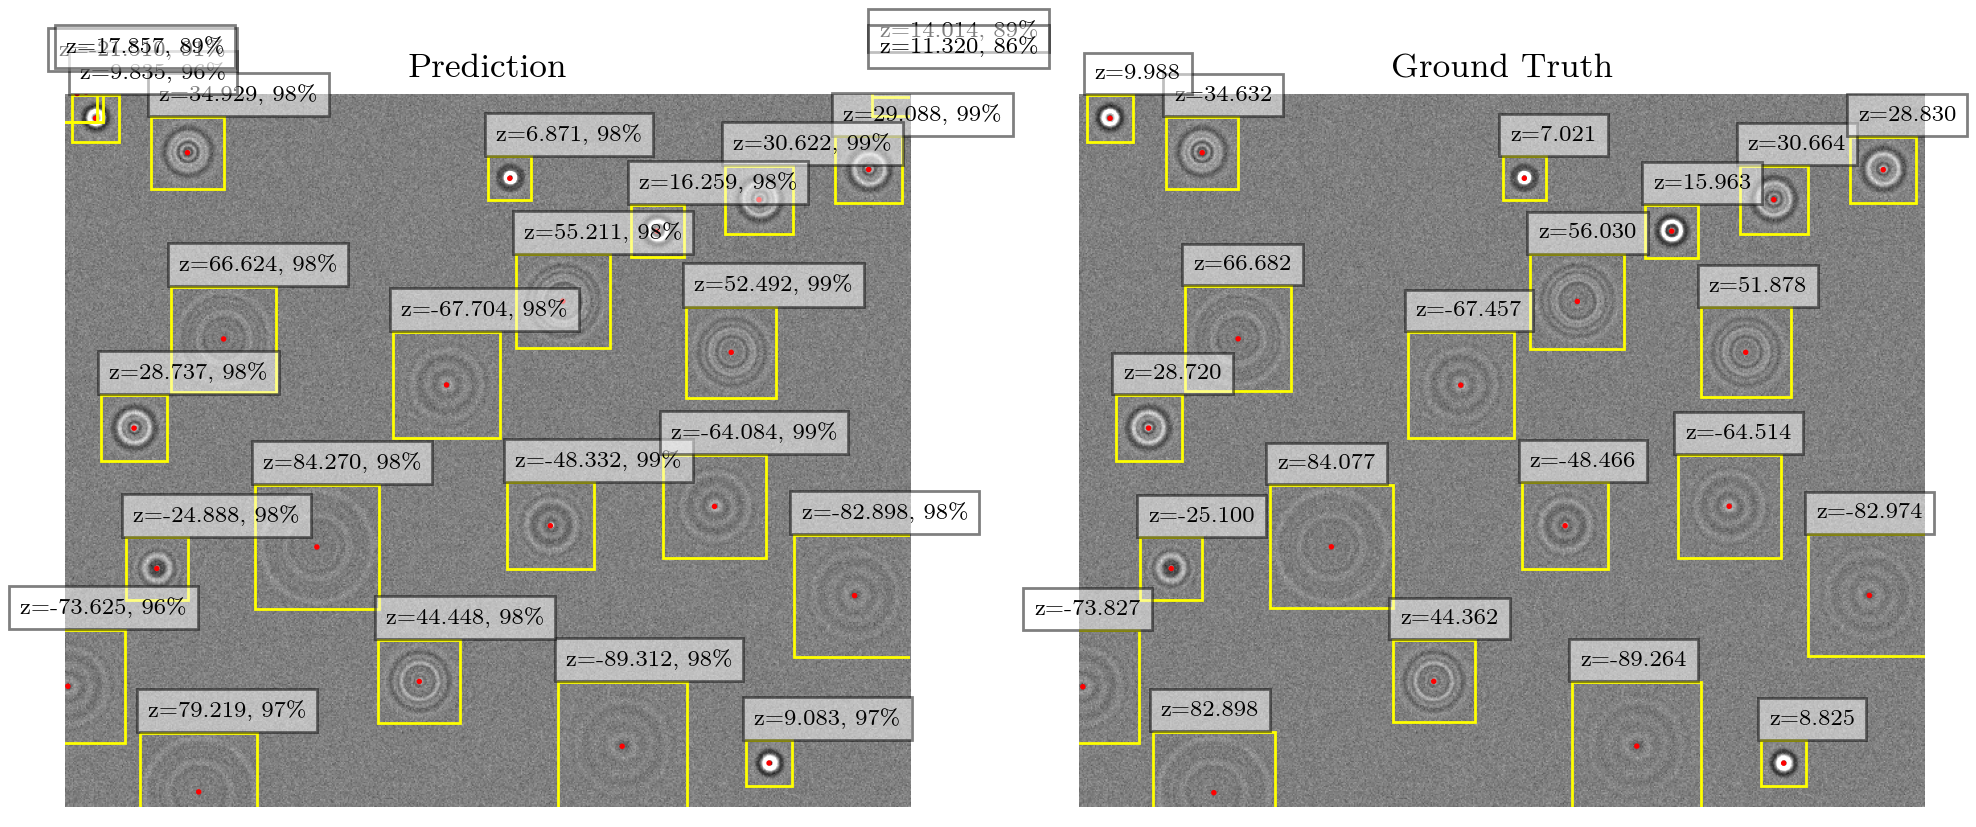

In [11]:
if not plt.get_fignums() : plt.figure(figsize=(12,5))
else: plt.clf()
image = random_image()
img = np.array(PIL.Image.open(image))
results = model.predict(np.array(img), conf = 0.7)
res = results[0].zaxis.data.cpu().numpy()
plt.subplot(1,2,1)
plt.title("Prediction")
kpt = res[:,8:]
bbox = res[:,:4]
z = res[:,6]
plot_result(plt.gca(),img,res[:,4],ops.xyxy2xywh(bbox),z,kpt,conf=res[:,4], vmin=1.95e4, vmax=2.05e4)
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Ground Truth")
plot_gt(image,plt.gca(),imgsz, vmin=1.95e4, vmax=2.05e4)
plt.show()



In [17]:

model_paths = "yolo11n_ripples_no_overlap.pt", "yolo11n_ripples.pt"
dataset_paths = "../datasets/ripples_no_overlap_slow.yaml", "../datasets/ripples_slow.yaml"
results = []
for model_path, dataset_path in zip(model_paths, dataset_paths):
    model = YOLOtrack11(model_path)
    res = model.val(data=dataset_path, workers=0, background_level=2e4, conf=0.8)
    results.append(res)


Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)


YOLO11n-zaxis summary (fused): 118 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_ripples/labels/val_no_overlap_slow.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 625/625 [00:17<00:00, 35.44it/s]


                   all      10000     235792          1          1      0.995      0.995      0.424      0.229
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 118 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_ripples/labels/val_slow.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 625/625 [00:25<00:00, 24.81it/s]


                   all      10000     599713          1      0.988      0.993      0.991        1.3      0.498
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image


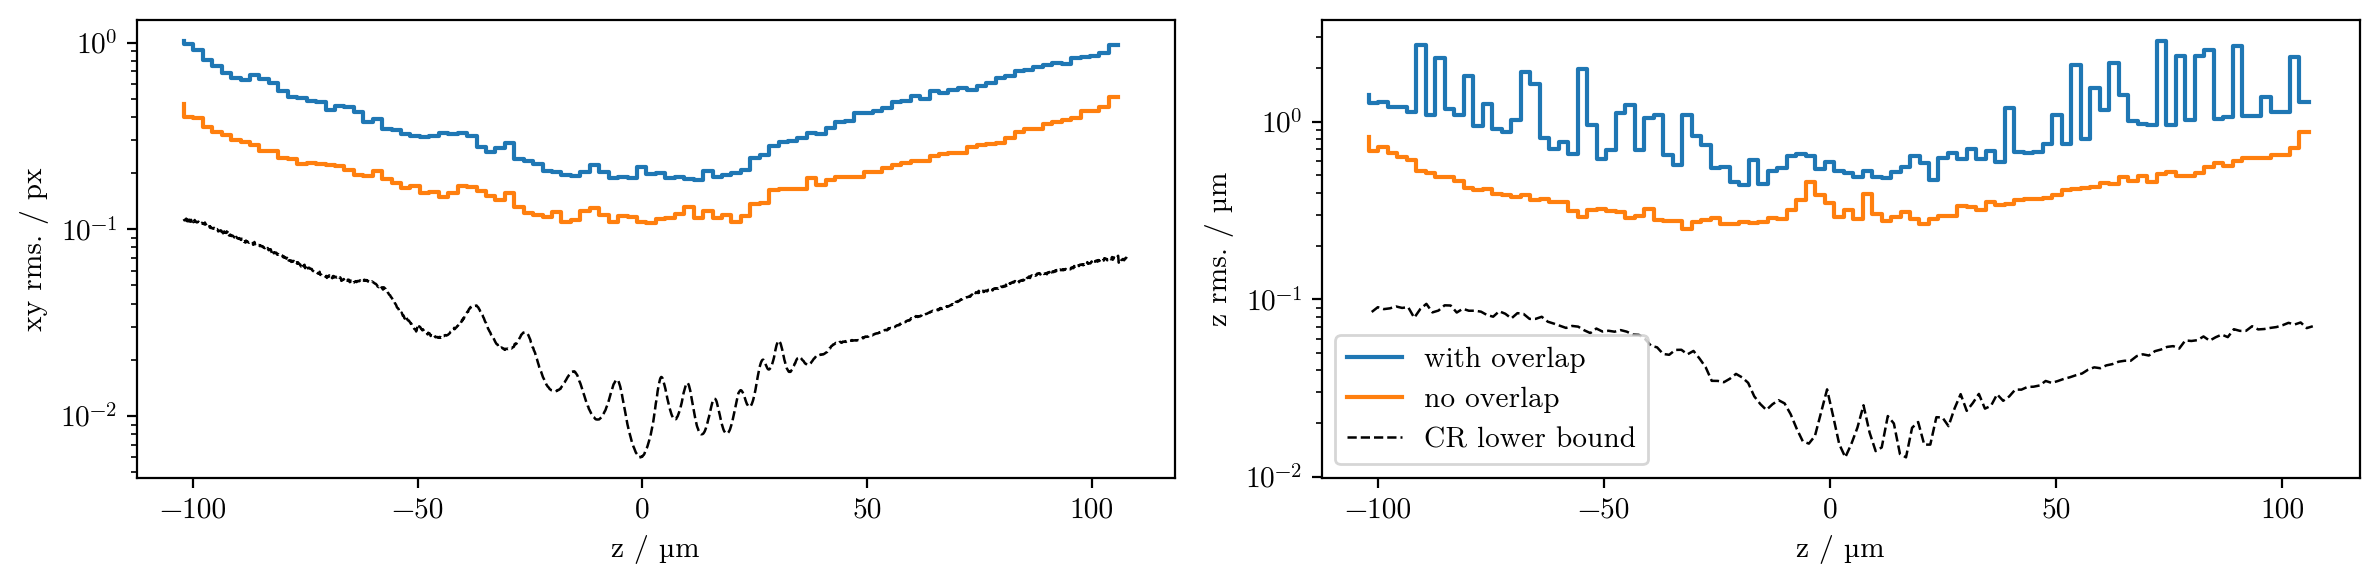

In [26]:
bins=100
plt.figure(figsize=(12,3))
plt.subplot(121)
crlb = np.load("crlb_results.npz")
y, x,_ = binned_statistic(results[1].z_pairs[6][0], results[1].xy_distances[6]**2, bins=bins)
plt.step(x[:-1],np.sqrt(y))
y, x,_ = binned_statistic(results[0].z_pairs[6][0], results[0].xy_distances[6]**2, bins=bins)
plt.step(x[:-1],np.sqrt(y))
# plt.hist(results[0].z_pairs[6][0], bins=bins)
plt.plot(crlb["z_space"], crlb["std_xy"], "--", c="k", lw=0.9)
plt.yscale("log")
plt.xlabel("z / µm")
plt.ylabel("xy rms. / px")

plt.subplot(122)
y, x,_ = binned_statistic(results[1].z_pairs[6][0], np.subtract(*results[1].z_pairs[6])**2, bins=bins)
plt.step(x[:-1],np.sqrt(y), label="with overlap")
y, x,_ = binned_statistic(results[0].z_pairs[6][0], np.subtract(*results[0].z_pairs[6])**2, bins=bins)
plt.step(x[:-1],np.sqrt(y), label="no overlap")
k=10
plt.plot(crlb["z_space"][k//2:-k//2:k], np.convolve(crlb["std_z"], np.ones(k)/k, mode='same')[k//2:-k//2:k], "--", c="k", lw=0.9, label="CR lower bound")
plt.yscale("log")
plt.xlabel("z / µm")
plt.ylabel("z rms. / µm")
plt.legend()
# plt.ylim(0,7.5)
plt.tight_layout()

It seems strange that here, the CRLB is 1 order of magnitude below the model's rms.

I see the following possibilities:

* we're in much better noise conditions compared to the spot images, so we are in the plateaued region (see previous chapter), but then, why isn't this plot perfectly flat at ~0.1px?
* the contrast is much lower so the network might have difficulties finding the shapes, so we might want to use a different normalization when loading the images

## How does the performance vary with the training set size?

Here: $SNR = 1...20$

In [4]:
num = 5000,10000,20000,50000
model_idx = 163,159,161,162,122

results = []
for i,n in zip(model_idx,num):
    model = YOLOtrack11(f"../../ultralytics/runs/pose/train{i}/weights/last.pt")
    results.append(model.val(save=False, data=f'../datasets/snr10-13.yaml', workers=0, conf=0.8))


Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 118 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_snr10-13.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 625/625 [00:24<00:00, 25.46it/s]


                   all      10000     603115       0.91      0.179      0.544      0.352       9.53       4.09
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 118 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_snr10-13.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 625/625 [00:20<00:00, 30.36it/s]


                   all      10000     603115      0.996      0.726      0.862      0.773       4.31       2.01
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 118 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_snr10-13.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 625/625 [00:20<00:00, 30.89it/s]


                   all      10000     603115      0.995      0.814      0.906      0.846       3.07       1.68
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 118 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_snr10-13.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 625/625 [00:19<00:00, 31.29it/s]


                   all      10000     603115      0.989       0.88      0.938      0.903       4.21       1.44
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image


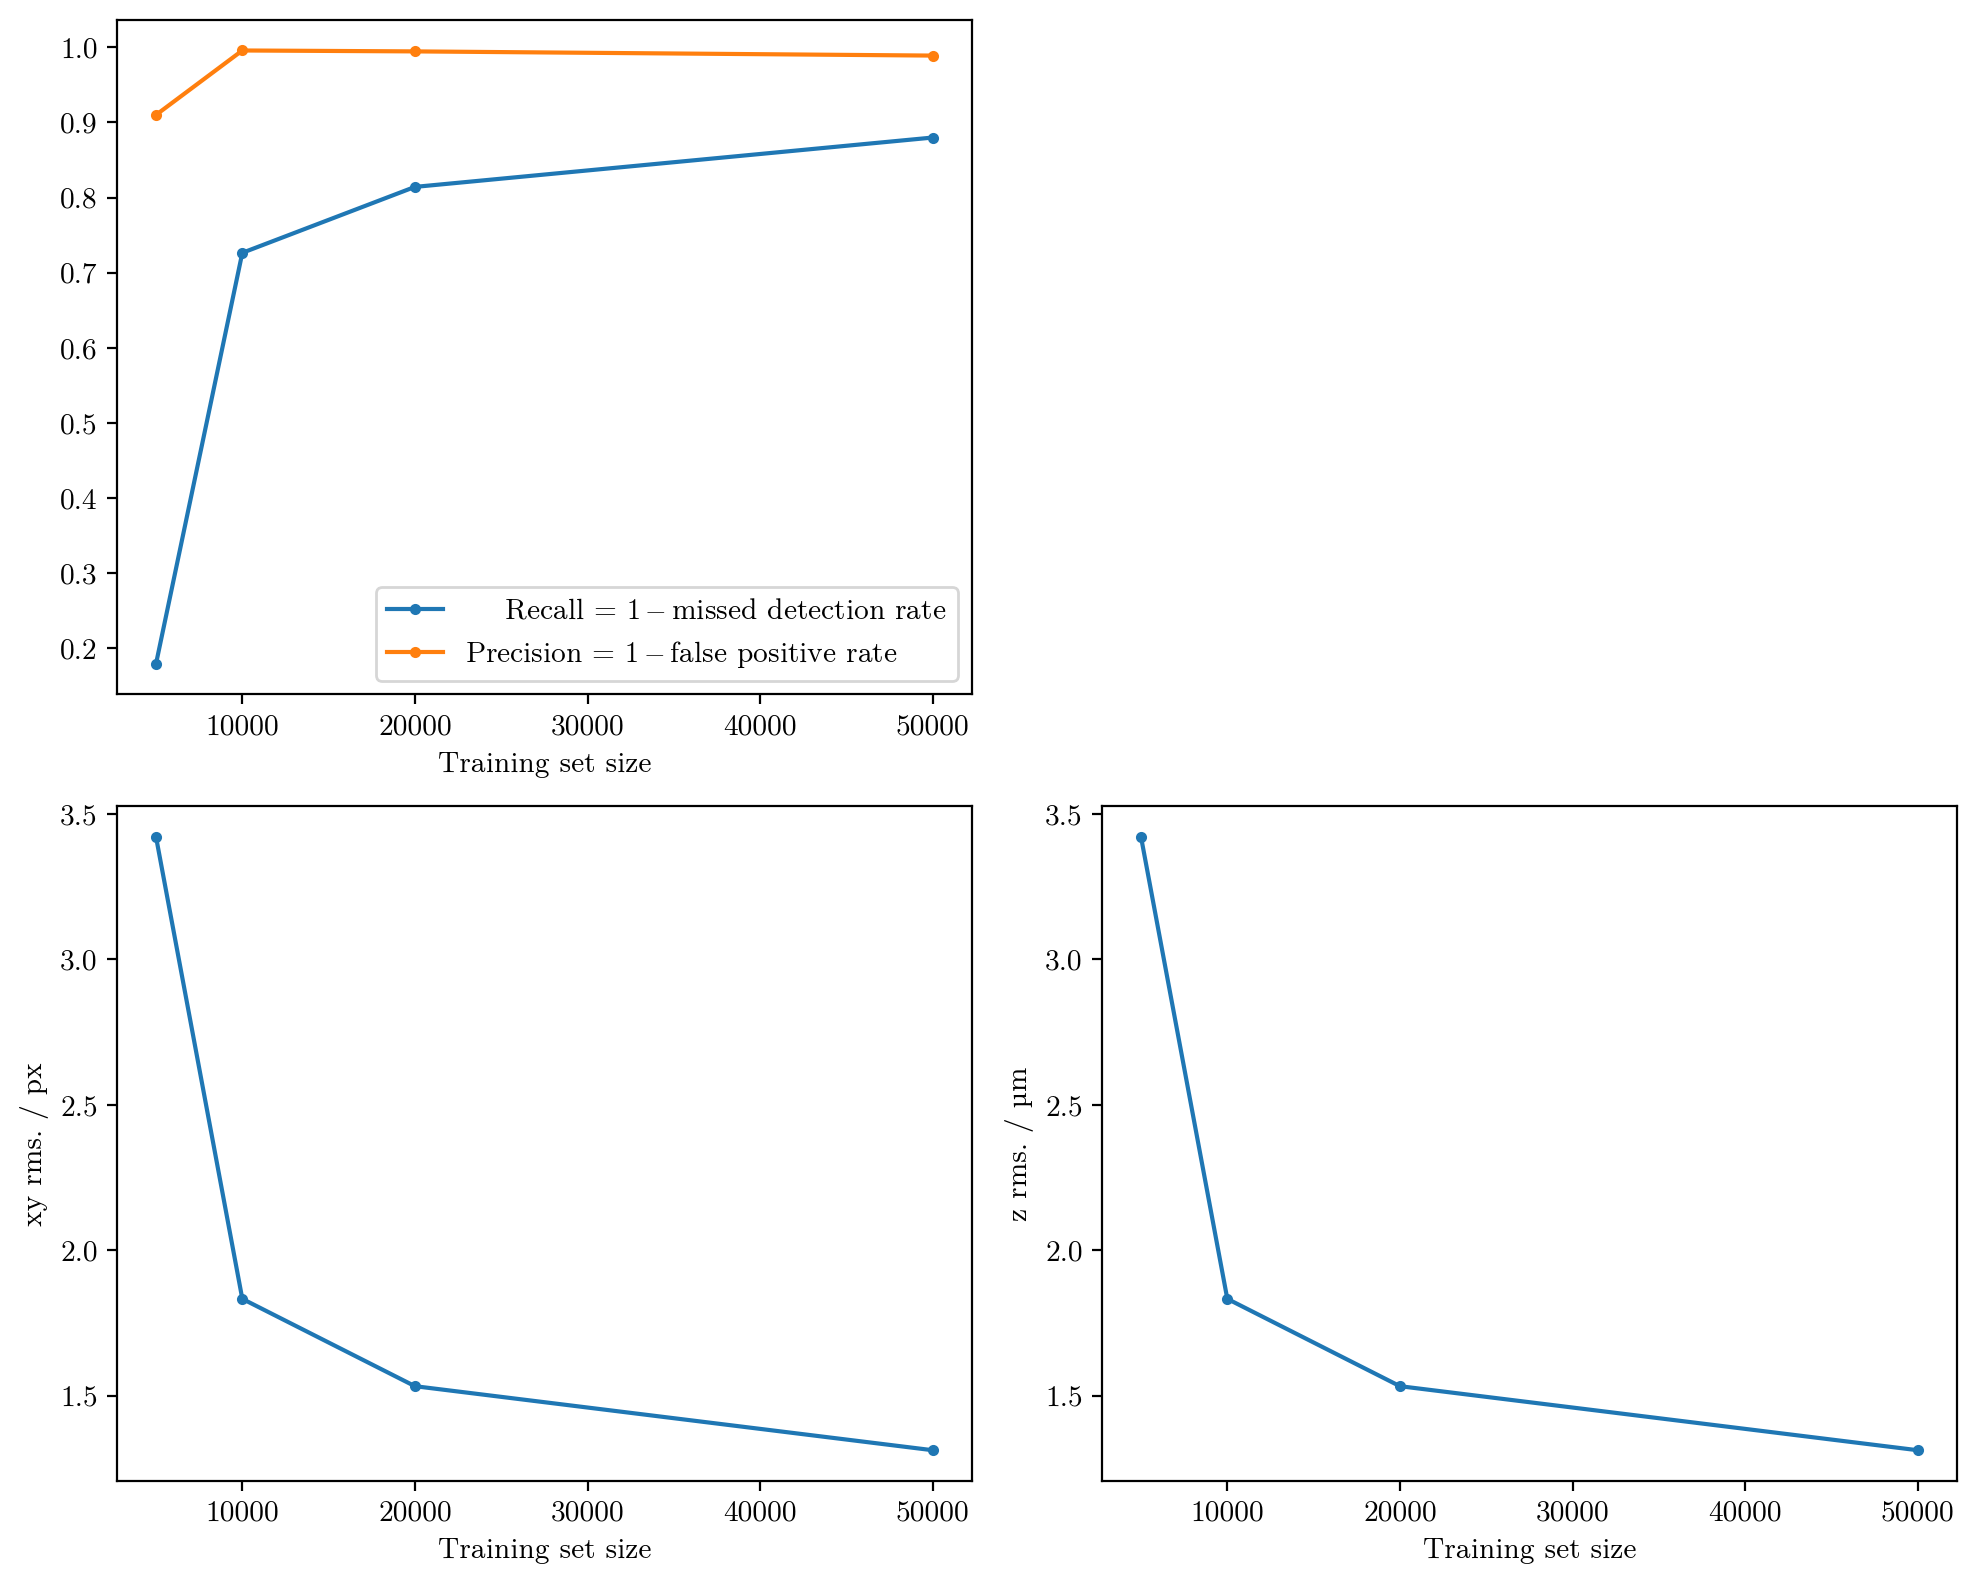

In [6]:

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.xlabel("Training set size")
plt.plot(num, [res.box.r for res in results], ".-",label="    Recall = $1 -$missed detection rate")
plt.plot(num, [res.box.p for res in results], ".-",label="Precision = $1 -$false positive rate")
plt.legend()

plt.subplot(2,2,3)
#plt.axvline(45,0,1,ls="dashed", lw=0.9, label="training lower noise bound")
#plt.axvline(50,0,1,ls="dashed", lw=0.9, label="training upper noise bound")
# plt.axvline(47,0,1,ls="dashed", lw=0.9, label="yundon's noise level")
plt.plot(num, [res.xy_rms[6] for res in results], ".-",)
plt.xlabel("Training set size")
plt.ylabel("xy rms. / px")
plt.subplot(2,2,4)
#plt.axvline(45,0,1,ls="dashed", lw=0.9, label="training lower noise bound")
#plt.axvline(50,0,1,ls="dashed", lw=0.9, label="training upper noise bound")
# plt.axvline(47,0,1,ls="dashed", lw=0.9, label="yundon's noise level")
plt.plot(num, [res.xy_rms[6] for res in results], ".-",)


plt.xlabel("Training set size")
plt.ylabel("z rms. / µm")
plt.tight_layout()
plt.show()




### Performance on real microscopic data

How do we get the model to be more effective on the actual data? Since the applicability of the model trained on synthetic data seems to be quite narrow, one approach is **fine tuning** an already converged model on real data.

In [4]:
import YOLOtrack11
modelfnames = ["../../ultralytics/runs/pose/train122/weights/last.pt","../../ultralytics/runs/pose/train129/weights/last.pt", "../../ultralytics/runs/pose/train122/weights/last.pt","../../ultralytics/runs/pose/train129/weights/last.pt","../../ultralytics/runs/pose/train143/weights/last.pt"]
models = [YOLOtrack11.YOLOtrack11(modelfname) for modelfname in modelfnames]
# print(model.model.model)
print("loaded")
# results = model.train(data="data_gen/data.yaml", epochs=100, imgsz=512,)
results = []
filenames = [f'../datasets/dataset_subpixel.yaml', f'../datasets/dataset_subpixel.yaml', f'../datasets/dataset_subpixel_real.yaml', f'../datasets/dataset_subpixel_real.yaml', f'../datasets/dataset_subpixel_real.yaml']
for model, fname  in zip(models, filenames):
    results.append(model.val(save=False,z_corr=False, data=fname, conf=0.8))

print("test")

loaded
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val.cache... 5000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 313/313 [00:08<00:00, 38.32it/s]


                   all       5000     307625      0.981      0.884       0.94      0.928       1.12       1.08
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val.cache... 5000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 313/313 [00:08<00:00, 38.46it/s]


                   all       5000     307625      0.981      0.912      0.954      0.942       2.53       1.16
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


...

YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_real.cache... 1196 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1196/1196 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 75/75 [00:02<00:00, 37.21it/s]


                   all       1196      63150      0.687      0.894      0.737      0.469       13.5       2.06
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_real.cache... 1196 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1196/1196 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 75/75 [00:01<00:00, 38.07it/s]

                   all       1196      63150       0.86      0.888      0.834      0.497       2.77       1.93
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
test


Here is an overview of the $xy$ and $z$ root mean square error on the whole training set

In [5]:

for res, name in zip(results, ["no fine tune","\nz fine tune","\nreal data:\nno fine tune","\n z fine tune", "\n z fine tune(real)"]):
    print(name)
    print("xy_rms =",res.xy_rms[5],"px")
    print("z_rms =",res.z_rms[5],"um")


no fine tune
xy_rms = 1.0736179 px
z_rms = 1.118449 um

z fine tune
xy_rms = 1.1266402 px
z_rms = 1.785709 um

real data:
no fine tune
xy_rms = 1.7527341 px
z_rms = 10.45958 um

 z fine tune
xy_rms = 1.7790414 px
z_rms = 11.790072 um

 z fine tune(real)
xy_rms = 1.4531882 px
z_rms = 4.3716326 um


Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_snr10-13.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 625/625 [00:24<00:00, 25.48it/s]


                   all      10000     603115      0.989       0.91      0.954      0.941       3.18        1.1
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_real.cache... 1044 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1044/1044 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 66/66 [00:02<00:00, 25.00it/s]

                   all       1044      55091      0.705      0.881      0.749       0.48       12.4       2.02
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.2ms postprocess per image


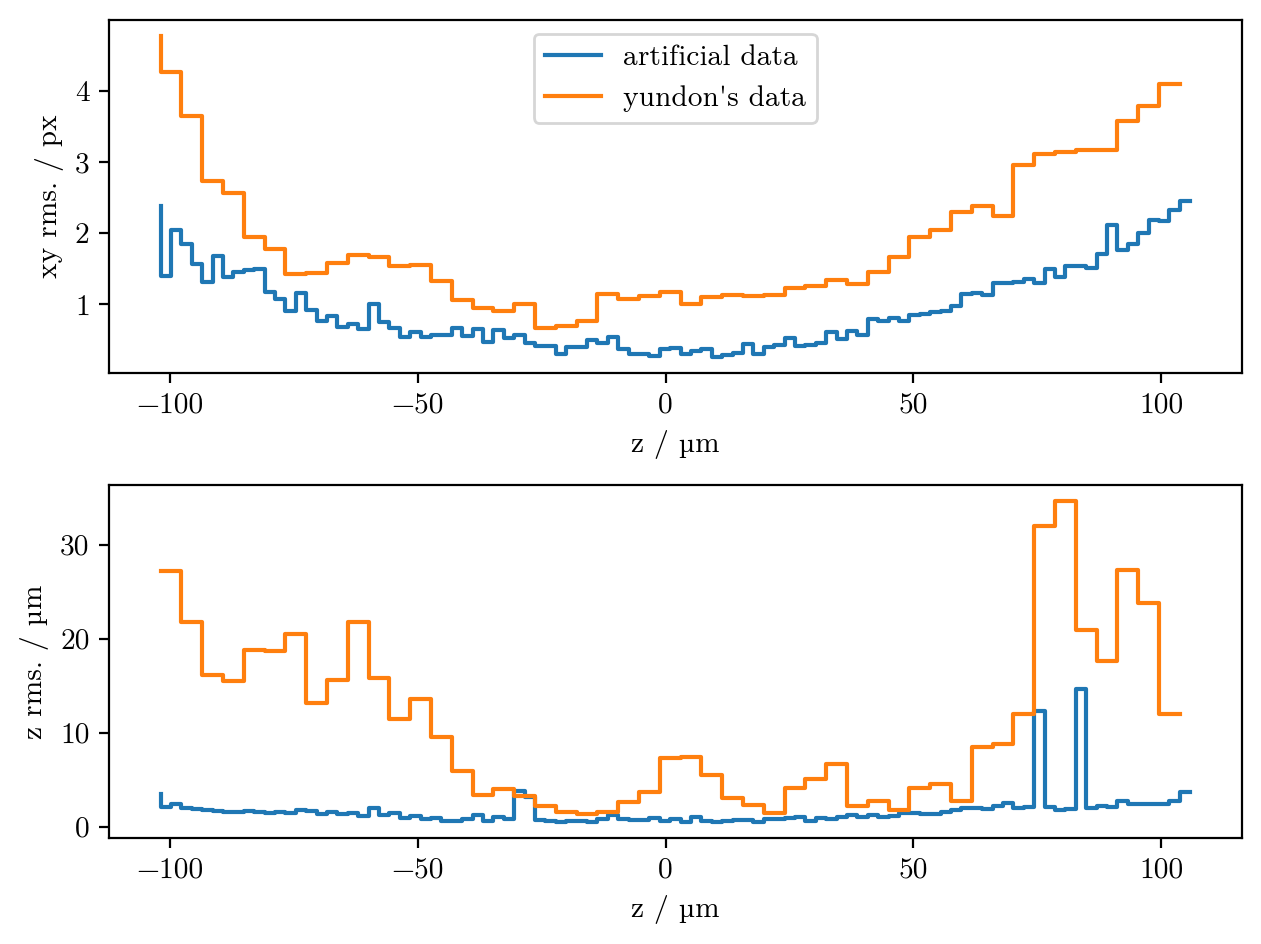

In [ ]:

results = []
for d in ["snr10-13.yaml", "dataset_subpixel_real.yaml"]:
    model = YOLOtrack11.YOLOtrack11(f"../../ultralytics/runs/pose/train122/weights/last.pt")
    results.append(model.val(save=False,z_corr=False, data=f'../datasets/{d}', workers=0, conf=0.8))

bins = 100

plt.subplot(211)
y, x,_ = binned_statistic(results[0].z_pairs[5][0], results[0].xy_distances[5]**2, bins=bins)
plt.step(x[:-1],np.sqrt(y), label="artificial data")
# plt.plot(clrb["z_space"], 50/0.75*clrb["std_xy"], "--")

plt.xlabel("z / µm")
plt.ylabel("xy rms. / px")
# plt.legend()
plt.subplot(212)
y, x,_ = binned_statistic(results[0].z_pairs[5][0], np.subtract(*results[0].z_pairs[5])**2, bins=bins)
plt.step(x[:-1],np.sqrt(y))
k=10
# plt.plot(clrb["z_space"][k//2:-k//2:k], 50/0.75*np.convolve(clrb["std_z"], np.ones(k)/k, mode='same')[k//2:-k//2:k], "--")
plt.xlabel("z / µm")
plt.ylabel("z rms. / µm")
# plt.ylim(0,7.5)
bins = 50
# plt.figure(figsize=(10,8))
plt.subplot(211)
y, x,_ = binned_statistic(results[1].z_pairs[5][0], results[1].xy_distances[5]**2, bins=bins)
plt.step(x[:-1],np.sqrt(y), label="yundon's data")
plt.xlabel("z / µm")
plt.ylabel("xy rms. / px")
plt.legend()

plt.subplot(212)
y, x,_ = binned_statistic(results[1].z_pairs[5][0], np.subtract(*results[1].z_pairs[5])**2, bins=bins)
plt.step(x[:-1],np.sqrt(y))
plt.xlabel("z / µm")
plt.ylabel("z rms. / µm")
# # plt.ylim(0,7.5)

plt.tight_layout()


Text(0, 0.5, 'pred. z / µm')

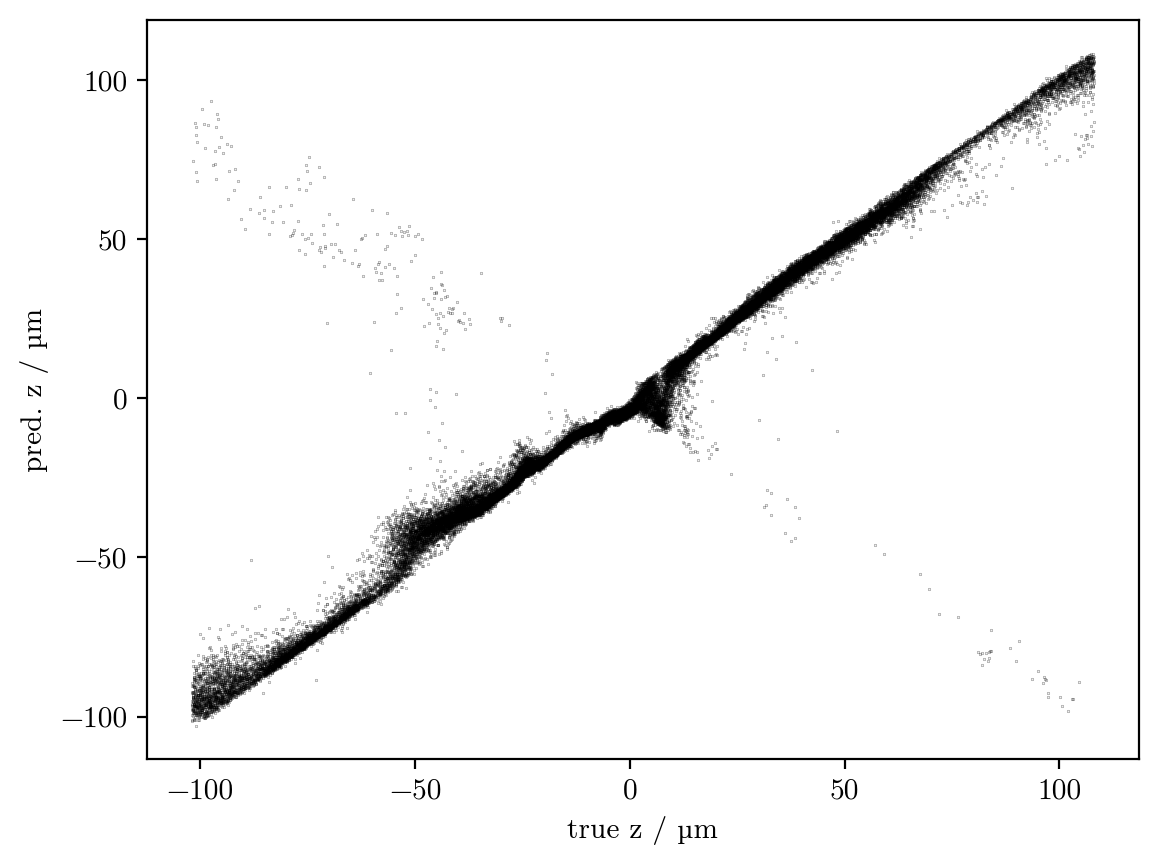

In [ ]:

plt.plot(results[1].z_pairs[5][0], results[1].z_pairs[5][1], "k.", ms=0.2, alpha=0.9)
plt.xlabel("true z / µm")
plt.ylabel("pred. z / µm")